In [19]:
import pandas as pd
df = pd.read_csv("../data/students.csv")
print(df, "Dataset loaded successfully!")

   student_name study_hours  attendance  previous_marks  assignment_score  \
0         Rahul           5        80.0            65.0              75.0   
1         Priya           7        90.0            78.0              85.0   
2          Amit           3        65.0            55.0              60.0   
3          Neha           6        85.0            72.0              80.0   
4          Ravi           4        70.0            60.0              68.0   
..          ...         ...         ...             ...               ...   
95        Pooja           7         NaN            82.0              84.0   
96        Karan           2        60.0            50.0              55.0   
97        Nitin           5        77.0             NaN              72.0   
98        Divya           8        96.0            90.0               NaN   
99          NaN           6        82.0            70.0              78.0   

    final_marks  
0          70.0  
1          82.0  
2          58.0  
3  

In [20]:
df.head()

,student_name,study_hours,attendance,previous_marks,assignment_score,final_marks
0,Rahul,5,80.0,65.0,75.0,70.0
1,Priya,7,90.0,78.0,85.0,82.0
2,Amit,3,65.0,55.0,60.0,58.0
3,Neha,6,85.0,72.0,80.0,76.0
4,Ravi,4,70.0,60.0,68.0,64.0


In [21]:
df.tail()

,student_name,study_hours,attendance,previous_marks,assignment_score,final_marks
95,Pooja,7,NaN,82.0,84.0,81.0
96,Karan,2,60.0,50.0,55.0,NaN
97,Nitin,5,77.0,NaN,72.0,69.0
98,Divya,8,96.0,90.0,NaN,92.0
99,NaN,6,82.0,70.0,78.0,75.0


In [22]:
df.shape

(100, 6)

In [23]:
df.columns

Index(['student_name', 'study_hours', 'attendance', 'previous_marks',
       'assignment_score', 'final_marks'],
      dtype='str')

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_name      99 non-null     str    
 1   study_hours       100 non-null    str    
 2   attendance        98 non-null     float64
 3   previous_marks    98 non-null     float64
 4   assignment_score  98 non-null     float64
 5   final_marks       98 non-null     float64
dtypes: float64(4), str(2)
memory usage: 4.8 KB


In [25]:
df.describe()

,attendance,previous_marks,assignment_score,final_marks
count,98.000000,98.000000,98.000000,98.000000
mean,79.653061,70.938776,75.357143,73.051020
std,14.718739,14.509021,14.544812,15.631301
min,-10.000000,47.000000,-5.000000,-20.000000
25%,71.000000,61.000000,66.250000,64.000000
50%,82.000000,70.500000,77.500000,75.000000
75%,90.000000,78.750000,85.000000,82.750000
max,105.000000,150.000000,96.000000,110.000000


In [27]:
df.isnull().sum()

student_name        1
study_hours         0
attendance          2
previous_marks      2
assignment_score    2
final_marks         2
dtype: int64

In [40]:
df[df.isnull().any(axis=1)]

,student_name,study_hours,attendance,previous_marks,assignment_score,final_marks
33,Neha,6,NaN,73.0,81.0,77.0
38,Arjun,5,79.0,NaN,75.0,72.0
39,Anjali,6,83.0,71.0,NaN,76.0
43,Simran,7,87.0,77.0,85.0,NaN
95,Pooja,7,NaN,82.0,84.0,81.0
96,Karan,2,60.0,50.0,55.0,NaN
97,Nitin,5,77.0,NaN,72.0,69.0
98,Divya,8,96.0,90.0,NaN,92.0
99,NaN,6,82.0,70.0,78.0,75.0


In [41]:
df.duplicated().sum()

np.int64(11)

In [42]:
df["student_name"].value_counts()

student_name
Rahul     4
Priya     4
Sneha     4
Karan     4
Pooja     4
Arjun     4
Meena     4
Nitin     4
Divya     4
Neha      3
Ravi      3
Anjali    3
Vikas     3
Rohit     3
Simran    3
Manish    3
Kavita    3
Deepak    3
Riya      3
Sahil     3
Komal     3
Aarti     3
Varun     3
Mohit     3
Isha      3
Gaurav    3
Tanya     3
Yash      3
Nisha     3
Amit      2
amit      1
Name: count, dtype: int64

In [50]:
df["student_name"]=(
    df["student_name"]
    .str.strip()
    .str.title()
    )

In [47]:
df["study_hours"]=pd.to_numeric(
    df["study_hours"],
    errors="coerce"
)

In [51]:
df.loc[df["study_hours"]<0,
       "study_hours"
       ]=pd.NA

In [52]:
df.loc[
    (df["attendance"]<0) | (df["attendance"]>100),
     "attendance"
]=pd.NA

In [54]:
df.loc[(df["previous_marks"]<0) | (df["previous_marks"]>100),
       "previous_marks"
]=pd.NA

In [55]:
df.loc[
    (df["assignment_score"]<0) | (df["assignment_score"]>100),
    "assignment_score"
]=pd.NA

In [56]:
df.loc[
    (df["final_marks"]<0) | (df["final_marks"]>100),
    "final_marks"
]=pd.NA

In [57]:
df["study_hours"]=df["study_hours"].fillna(
    df["study_hours"].median()
)

In [58]:
df["attendance"]=df["attendance"].fillna(
    df["attendance"].median()
)

In [59]:
df["previous_marks"]=df["previous_marks"].fillna(
    df["previous_marks"].median()
)

In [60]:
df["assignment_score"] = df["assignment_score"].fillna(
    df["assignment_score"].median()
)

In [61]:
df=df.dropna(subset=["final_marks"])

In [64]:
df=df.dropna(subset=["student_name"])

In [66]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 11


In [67]:
df=df.drop_duplicates()

In [68]:
df=df.reset_index(drop=True)

In [69]:
df.to_csv("../data/students_cleaned.csv",index=False)

In [71]:
print(df.isnull().sum())

student_name        0
study_hours         0
attendance          0
previous_marks      0
assignment_score    0
final_marks         0
dtype: int64


In [72]:
print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [73]:
import pandas as pd
df=pd.read_csv("../data/students_cleaned.csv")
print(df.head())

  student_name  study_hours  attendance  previous_marks  assignment_score  \
0        Rahul          5.0        80.0            65.0              75.0   
1        Priya          7.0        90.0            78.0              85.0   
2         Amit          3.0        65.0            55.0              60.0   
3         Neha          6.0        85.0            72.0              80.0   
4         Ravi          4.0        70.0            60.0              68.0   

   final_marks  
0         70.0  
1         82.0  
2         58.0  
3         76.0  
4         64.0  


In [74]:
print("Rows and Columns:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Rows and Columns: (84, 6)

Columns:
Index(['student_name', 'study_hours', 'attendance', 'previous_marks',
       'assignment_score', 'final_marks'],
      dtype='str')

Data Types:
student_name            str
study_hours         float64
attendance          float64
previous_marks      float64
assignment_score    float64
final_marks         float64
dtype: object


In [75]:
print(df.describe())

       study_hours  attendance  previous_marks  assignment_score  final_marks
count    84.000000   84.000000       84.000000         84.000000    84.000000
mean      5.714286   80.071429       69.797619         75.821429    73.071429
std       2.805208   11.050580       11.898952         11.735191    12.235427
min       2.000000   57.000000       47.000000         51.000000    49.000000
25%       4.000000   71.000000       61.000000         66.750000    64.000000
50%       6.000000   82.000000       70.000000         77.500000    72.000000
75%       7.000000   89.250000       78.000000         85.000000    82.250000
max      25.000000   98.000000       92.000000         96.000000    94.000000


In [76]:
print("Average Study Hours:", df["study_hours"].mean())
print("Average Attendance:", df["attendance"].mean())
print("Average Previous Marks:", df["previous_marks"].mean())
print("Average Assignment Score:", df["assignment_score"].mean())
print("Average Final Marks:", df["final_marks"].mean())

Average Study Hours: 5.714285714285714
Average Attendance: 80.07142857142857
Average Previous Marks: 69.79761904761905
Average Assignment Score: 75.82142857142857
Average Final Marks: 73.07142857142857


In [77]:
print("Median Study Hours:", df["study_hours"].median())
print("Median Attendance:", df["attendance"].median())
print("Median Previous Marks:", df["previous_marks"].median())
print("Median Assignment Score:", df["assignment_score"].median())
print("Median Final Marks:", df["final_marks"].median())

Median Study Hours: 6.0
Median Attendance: 82.0
Median Previous Marks: 70.0
Median Assignment Score: 77.5
Median Final Marks: 72.0


In [79]:
print("Study Hours:")
print("Minimum:", df["study_hours"].min())
print("Maximum:", df["study_hours"].max())

print("\nAttendance:")
print("Minimum:", df["attendance"].min())
print("Maximum:", df["attendance"].max())

print("\nFinal Marks:")
print("Minimum:", df["final_marks"].min())
print("Maximum:", df["final_marks"].max())

Study Hours:
Minimum: 2.0
Maximum: 25.0

Attendance:
Minimum: 57.0
Maximum: 98.0

Final Marks:
Minimum: 49.0
Maximum: 94.0


In [80]:
print(df.sort_values(by="final_marks",ascending=False).head(10))

   student_name  study_hours  attendance  previous_marks  assignment_score  \
77        Divya          8.0        98.0            92.0              96.0   
52        Divya          8.0        97.0            91.0              95.0   
68        Meena          8.0        94.0            89.0              93.0   
23        Divya          8.0        96.0            90.0              94.0   
83        Divya          8.0        96.0            90.0              78.0   
80        Nisha          8.0        94.0            88.0              91.0   
41        Meena          8.0        93.0            89.0              92.0   
58        Nisha          8.0        94.0            88.0              90.0   
11        Meena          8.0        92.0            88.0              91.0   
46         Riya          8.0        95.0            87.0              93.0   

    final_marks  
77         94.0  
52         93.0  
68         92.0  
23         92.0  
83         92.0  
80         91.0  
41         91.0

In [81]:
print(df.sort_values(
    by="final_marks",
    ascending=True
).head(10))

   student_name  study_hours  attendance  previous_marks  assignment_score  \
45       Deepak          2.0        57.0            47.0              51.0   
16       Deepak          2.0        58.0            48.0              52.0   
73       Deepak          2.0        59.0            48.0              52.0   
36        Karan          6.0        59.0            49.0              54.0   
6         Karan          2.0        60.0            50.0              55.0   
51        Varun          3.0        62.0            53.0              58.0   
76        Varun          3.0        64.0            54.0              59.0   
22        Varun          3.0        63.0            54.0              59.0   
32         Amit          3.0        64.0            55.0              61.0   
61         Amit          3.0        82.0            56.0              62.0   

    final_marks  
45         49.0  
16         50.0  
73         50.0  
36         51.0  
6          52.0  
51         55.0  
76         56.0

In [83]:
high_marks=df[df["final_marks"]>=80]
high_marks

,student_name,study_hours,attendance,previous_marks,assignment_score,final_marks
1,Priya,7.0,90.0,78.0,85.0,82.0
5,Sneha,8.0,95.0,85.0,90.0,88.0
7,Pooja,7.0,88.0,75.0,82.0,80.0
11,Meena,8.0,92.0,88.0,91.0,90.0
13,Simran,7.0,86.0,76.0,84.0,81.0
17,Riya,8.0,94.0,86.0,92.0,89.0
19,Komal,7.0,91.0,80.0,87.0,84.0
23,Divya,8.0,96.0,90.0,94.0,92.0
25,Isha,7.0,87.0,77.0,85.0,82.0
29,Nisha,8.0,93.0,87.0,89.0,90.0


In [84]:
students=df[df["study_hours"]>=6]
students

,student_name,study_hours,attendance,previous_marks,assignment_score,final_marks
1,Priya,7.0,90.0,78.0,85.0,82.0
3,Neha,6.0,85.0,72.0,80.0,76.0
5,Sneha,8.0,95.0,85.0,90.0,88.0
7,Pooja,7.0,88.0,75.0,82.0,80.0
9,Anjali,6.0,82.0,70.0,78.0,75.0
11,Meena,8.0,92.0,88.0,91.0,90.0
13,Simran,7.0,86.0,76.0,84.0,81.0
15,Kavita,6.0,89.0,74.0,83.0,79.0
17,Riya,8.0,94.0,86.0,92.0,89.0
19,Komal,7.0,91.0,80.0,87.0,84.0


In [86]:
correlation=df.corr(numeric_only=True)
print(correlation["final_marks"].sort_values(ascending=False))

final_marks         1.000000
previous_marks      0.992746
assignment_score    0.979904
attendance          0.973825
study_hours         0.618756
Name: final_marks, dtype: float64


In [87]:
# DATA VISUALIZATION
import pandas as pd
import matplotlib.pyplot as plt

In [89]:
df = pd.read_csv("../data/students_cleaned.csv")
df.head()

,student_name,study_hours,attendance,previous_marks,assignment_score,final_marks
0,Rahul,5.0,80.0,65.0,75.0,70.0
1,Priya,7.0,90.0,78.0,85.0,82.0
2,Amit,3.0,65.0,55.0,60.0,58.0
3,Neha,6.0,85.0,72.0,80.0,76.0
4,Ravi,4.0,70.0,60.0,68.0,64.0


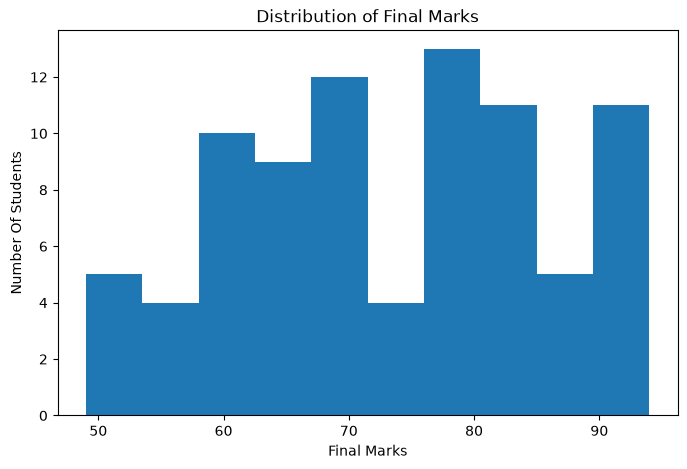

In [90]:
plt.figure(figsize=(8,5))
plt.hist(df["final_marks"],bins=10)
plt.xlabel("Final Marks")
plt.ylabel("Number Of Students")
plt.title("Distribution of Final Marks")
plt.show()

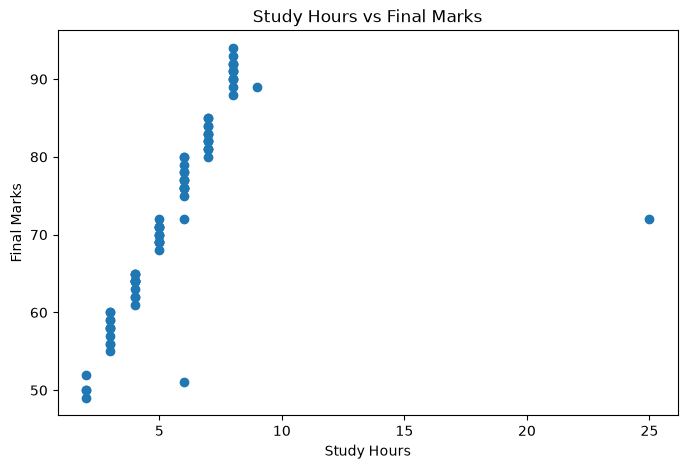

In [91]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["study_hours"],
    df["final_marks"]
)
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")
plt.show()

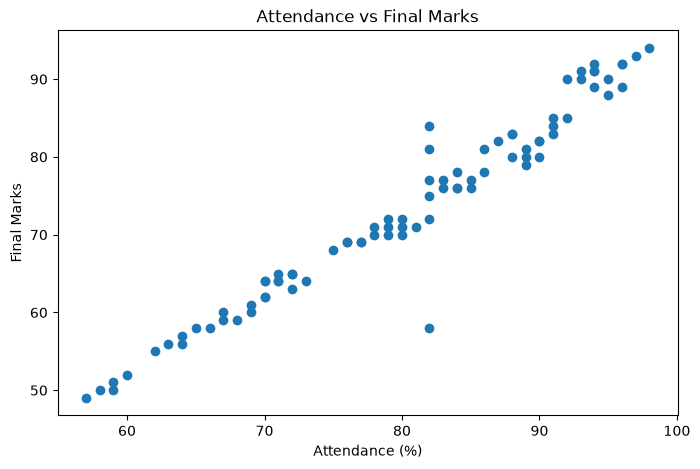

In [92]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["attendance"],
    df["final_marks"]
)
plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")
plt.show()

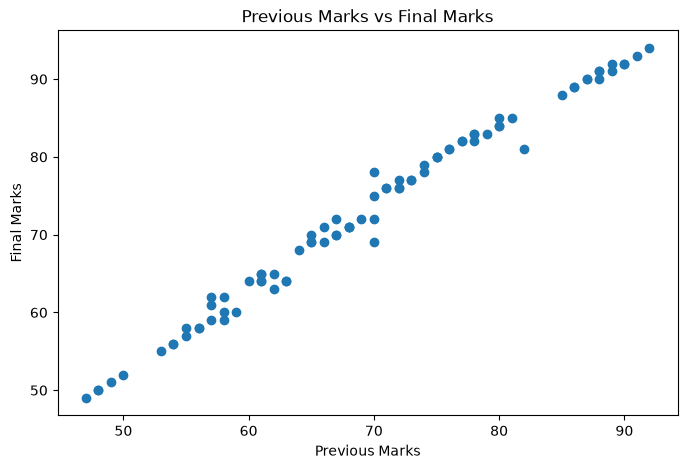

In [93]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["previous_marks"],
    df["final_marks"]
)
plt.xlabel("Previous Marks")
plt.ylabel("Final Marks")
plt.title("Previous Marks vs Final Marks")
plt.show()

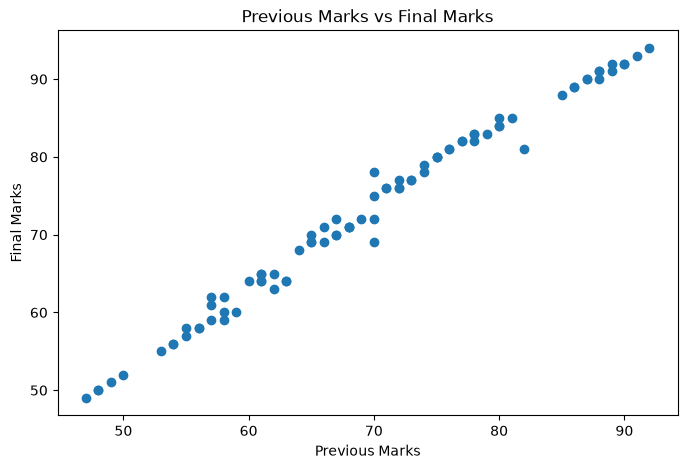

In [94]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["previous_marks"],
    df["final_marks"]
)
plt.xlabel("Previous Marks")
plt.ylabel("Final Marks")
plt.title("Previous Marks vs Final Marks")
plt.show()

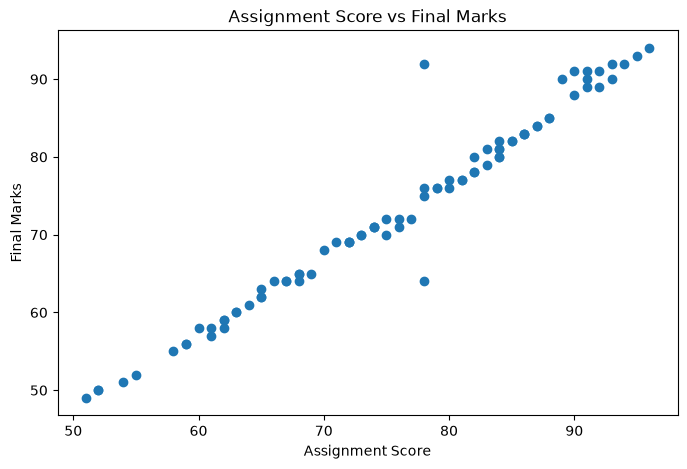

In [97]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["assignment_score"],
    df["final_marks"]
)
plt.xlabel("Assignment Score")
plt.ylabel("Final Marks")
plt.title("Assignment Score vs Final Marks")
plt.show()

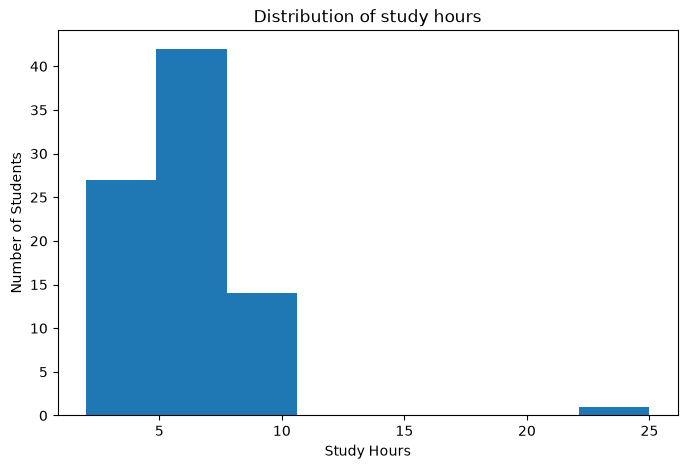

In [99]:
plt.figure(figsize=(8,5))
plt.hist(
    df["study_hours"],
    bins=8
)
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.title("Distribution of study hours")
plt.show()

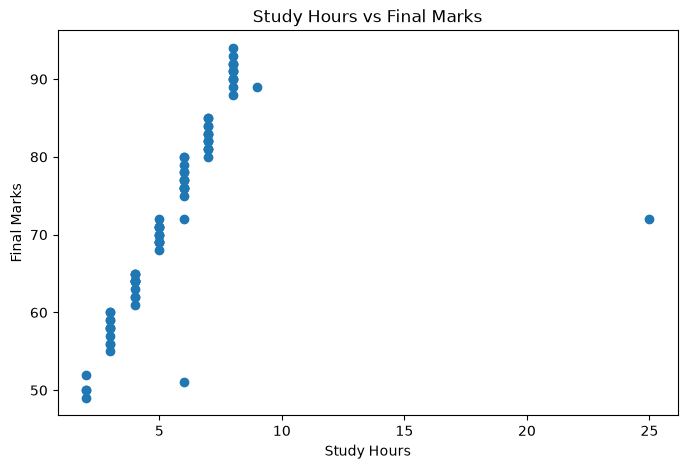

In [100]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["study_hours"],
    df["final_marks"]
)
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")
plt.savefig("../data/study_hours_vs_final_marks.png")

plt.show()

In [101]:
# FEATURES (X) & TARGET (y)
import pandas as pd
df=pd.read_csv("../data/students_cleaned.csv")
df

,student_name,study_hours,attendance,previous_marks,assignment_score,final_marks
0,Rahul,5.0,80.0,65.0,75.0,70.0
1,Priya,7.0,90.0,78.0,85.0,82.0
2,Amit,3.0,65.0,55.0,60.0,58.0
3,Neha,6.0,85.0,72.0,80.0,76.0
4,Ravi,4.0,70.0,60.0,68.0,64.0
...,...,...,...,...,...,...
79,Gaurav,5.0,79.0,68.0,74.0,71.0
80,Nisha,8.0,94.0,88.0,91.0,91.0
81,Pooja,7.0,82.0,82.0,84.0,81.0
82,Nitin,5.0,77.0,70.0,72.0,69.0


In [105]:
X=df[["study_hours","attendance","previous_marks","assignment_score"]]
print("X shape:",X.shape)
Y=df["final_marks"]
print("Y shape:",Y.shape)


X shape: (84, 4)
Y shape: (84,)


In [109]:
print("===== FEATURES (X) =====")
print(X.head())

print("\n===== TARGET (Y) =====")
print(Y.head())

===== FEATURES (X) =====
   study_hours  attendance  previous_marks  assignment_score
0          5.0        80.0            65.0              75.0
1          7.0        90.0            78.0              85.0
2          3.0        65.0            55.0              60.0
3          6.0        85.0            72.0              80.0
4          4.0        70.0            60.0              68.0

===== TARGET (Y) =====
0    70.0
1    82.0
2    58.0
3    76.0
4    64.0
Name: final_marks, dtype: float64


In [112]:
# Train_Test_Split
from sklearn.model_selection import train_test_split

X_train,X_test, Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [114]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (67, 4)
X_test shape: (17, 4)
Y_train shape: (67,)
Y_test shape: (17,)


In [116]:
print("===== X_train =====")
print(X_train.head())

print("\n===== Y_train =====")
print(Y_train.head())

===== X_train =====
    study_hours  attendance  previous_marks  assignment_score
76          3.0        64.0            54.0              59.0
42          3.0        67.0            59.0              63.0
49          5.0        78.0            67.0              73.0
11          8.0        92.0            88.0              91.0
30          5.0        81.0            66.0              76.0

===== Y_train =====
76    56.0
42    60.0
49    70.0
11    90.0
30    71.0
Name: final_marks, dtype: float64


In [117]:
print("===== X_test =====")
print(X_test.head())

print("\n===== Y_test =====")
print(Y_test.head())

===== X_test =====
    study_hours  attendance  previous_marks  assignment_score
73          2.0        59.0            48.0              52.0
0           5.0        80.0            65.0              75.0
58          8.0        94.0            88.0              90.0
22          3.0        63.0            54.0              59.0
12          3.0        68.0            58.0              62.0

===== Y_test =====
73    50.0
0     70.0
58    91.0
22    56.0
12    59.0
Name: final_marks, dtype: float64


In [120]:
# Linear Regression
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.04,0.17,0.67,0.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['study_hours','attendance','previous_marks','assignment_score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.041
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [121]:
print("Coefficients:")
print(model.coef_)

Coefficients:
[0.04127693 0.16843708 0.6683985  0.2079669 ]


In [122]:
print("Intercept:")
print(model.intercept_)

Intercept:
-3.0411900625542074


In [123]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: -3.0411900625542074
study_hours : 0.041276925518662654
attendance : 0.16843708212242314
previous_marks : 0.6683985018438372
assignment_score : 0.20796689877965377


In [124]:
Y_pred=model.predict(X_test)

In [125]:
comparison = pd.DataFrame({
    "Actual Marks": Y_test.values,
    "Predicted Marks": Y_pred
})

print(comparison)

    Actual Marks  Predicted Marks
0           50.0        49.876558
1           70.0        69.683581
2           91.0        90.658200
3           56.0        56.057743
4           59.0        60.197423
5           83.0        82.090448
6           63.0        64.209943
7           61.0        60.154672
8           64.0        63.160173
9           72.0        72.606419
10          64.0        65.254746
11          62.0        61.199475
12          89.0        89.907521
13          81.0        83.337486
14          71.0        71.480810
15          83.0        82.090448
16          77.0        76.656722


In [126]:
print("Model trained successfully!")
print("Number of predictions:", len(Y_pred))

Model trained successfully!
Number of predictions: 17


In [127]:
print(comparison.head(10))

   Actual Marks  Predicted Marks
0          50.0        49.876558
1          70.0        69.683581
2          91.0        90.658200
3          56.0        56.057743
4          59.0        60.197423
5          83.0        82.090448
6          63.0        64.209943
7          61.0        60.154672
8          64.0        63.160173
9          72.0        72.606419


In [128]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("===== MODEL EVALUATION =====")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

===== MODEL EVALUATION =====
MAE : 0.7930478200343086
MSE : 0.9074815272928978
RMSE: 0.952618248456798
R2 Score: 0.9932804980428479


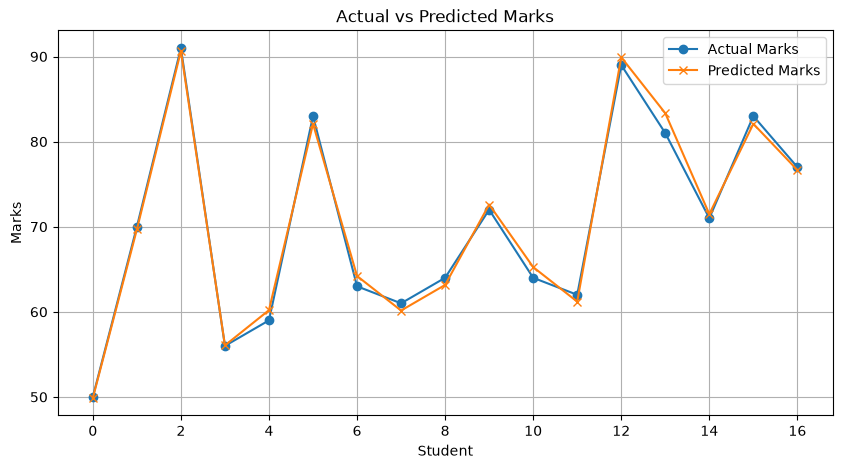

In [129]:
# Actual vs Predicted Line Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    Y_test.values,
    label="Actual Marks",
    marker="o"
)

plt.plot(
    Y_pred,
    label="Predicted Marks",
    marker="x"
)

plt.xlabel("Student")
plt.ylabel("Marks")
plt.title("Actual vs Predicted Marks")

plt.legend()
plt.grid(True)

plt.show()

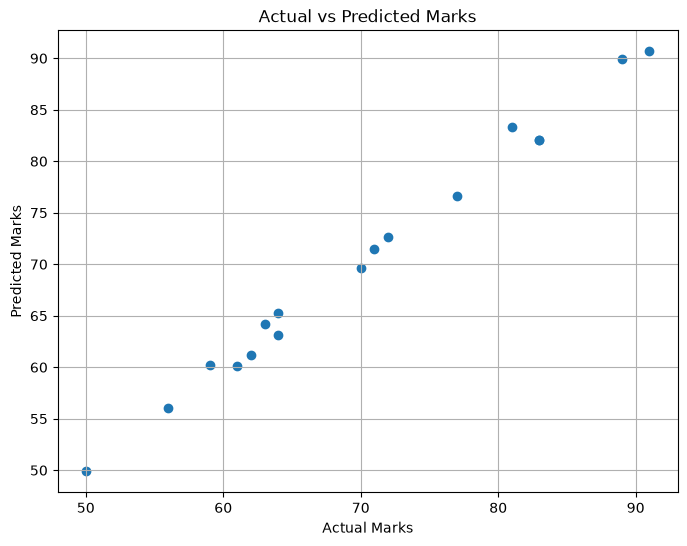

In [130]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    Y_test,
    Y_pred
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.grid(True)

plt.show()

In [131]:
comparison["Error"] = (
    comparison["Actual Marks"]
    - comparison["Predicted Marks"]
)

print(comparison)

    Actual Marks  Predicted Marks     Error
0           50.0        49.876558  0.123442
1           70.0        69.683581  0.316419
2           91.0        90.658200  0.341800
3           56.0        56.057743 -0.057743
4           59.0        60.197423 -1.197423
5           83.0        82.090448  0.909552
6           63.0        64.209943 -1.209943
7           61.0        60.154672  0.845328
8           64.0        63.160173  0.839827
9           72.0        72.606419 -0.606419
10          64.0        65.254746 -1.254746
11          62.0        61.199475  0.800525
12          89.0        89.907521 -0.907521
13          81.0        83.337486 -2.337486
14          71.0        71.480810 -0.480810
15          83.0        82.090448  0.909552
16          77.0        76.656722  0.343278


In [132]:
import joblib

# Save trained model
joblib.dump(
    model,
    "../model/linear_regression_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [138]:
import joblib

# Load saved model
loaded_model = joblib.load(
    "../model/linear_regression_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [139]:
import pandas as pd

new_student = pd.DataFrame({
    "study_hours": [6],
    "attendance": [85],
    "previous_marks": [75],
    "assignment_score": [80]
})

new_prediction = loaded_model.predict(new_student)

print("Predicted Marks:", new_prediction[0])

Predicted Marks: 78.29086301162383


In [141]:
import pandas as pd

new_student = pd.DataFrame({
    "student_name": ["Rahul"],
    "study_hours": [6],
    "attendance": [85],
    "previous_marks": [75],
    "assignment_score": [80]
})

features = [
    "study_hours",
    "attendance",
    "previous_marks",
    "assignment_score"
]

new_prediction = loaded_model.predict(
    new_student[features]
)

new_student["predicted_marks"] = new_prediction

print("===== STUDENT PREDICTION =====")
print(new_student)

new_student.to_csv(
    "../data/prediction_results.csv",
    index=False
)

print("Prediction saved successfully!")

===== STUDENT PREDICTION =====
  student_name  study_hours  attendance  previous_marks  assignment_score  \
0        Rahul            6          85              75                80   

   predicted_marks  
0        78.290863  
Prediction saved successfully!


In [143]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="mahak1234",
    database="student_marks_db",
    port=3306
)

print("MySQL connected successfully!")

MySQL connected successfully!


In [144]:
print(connection.is_connected())

True


In [145]:
cursor = connection.cursor()

print("Cursor created successfully!")

Cursor created successfully!


In [146]:
insert_query = """
INSERT INTO predictions (
    student_name,
    study_hours,
    attendance,
    previous_marks,
    assignment_score,
    predicted_marks
)
VALUES (%s, %s, %s, %s, %s, %s)
"""

In [151]:
student_values = (

    str(new_student["student_name"].iloc[0]),

    float(new_student["study_hours"].iloc[0]),

    float(new_student["attendance"].iloc[0]),

    float(new_student["previous_marks"].iloc[0]),

    float(new_student["assignment_score"].iloc[0]),

    float(new_student["predicted_marks"].iloc[0])

)

print(student_values)

('Rahul', 6.0, 85.0, 75.0, 80.0, 78.29086301162383)


In [154]:
cursor.execute(
    insert_query,
    student_values
)

In [156]:
connection.commit()
print("Prediction saved to MySQL successfully!")

Prediction saved to MySQL successfully!


In [159]:
cursor.close()
connection.close()

print("MySQL connection closed.")

MySQL connection closed.


In [167]:
import mysql.connector
import pandas as pd


# ==========================================
# 1. MYSQL CONNECTION
# ==========================================

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="mahak1234",
    database="student_marks_db",
    port=3306
)

print("MySQL connected successfully!")


# ==========================================
# 2. CREATE CURSOR
# ==========================================

cursor = connection.cursor()


# ==========================================
# 3. SELECT QUERY
# ==========================================

select_query = """
SELECT
    id,
    student_name,
    study_hours,
    attendance,
    previous_marks,
    assignment_score,
    predicted_marks
FROM predictions
"""


# ==========================================
# 4. EXECUTE QUERY
# ==========================================

cursor.execute(select_query)


# ==========================================
# 5. FETCH DATA
# ==========================================

results = cursor.fetchall()


# ==========================================
# 6. CONVERT TO DATAFRAME
# ==========================================

columns = [
    "id",
    "student_name",
    "study_hours",
    "attendance",
    "previous_marks",
    "assignment_score",
    "predicted_marks"
]

predictions_df = pd.DataFrame(
    results,
    columns=columns
)


# ==========================================
# 7. DISPLAY DATA
# ==========================================

print("\n===== SAVED PREDICTIONS =====")
print(predictions_df)


# ==========================================
# 8. CLOSE CONNECTION
# ==========================================

cursor.close()
connection.close()

print("\nMySQL connection closed.")

MySQL connected successfully!

===== SAVED PREDICTIONS =====
   id student_name  study_hours  attendance  previous_marks  assignment_score  \
0   1        Rahul          6.0        85.0            75.0              80.0   

   predicted_marks  
0          78.2909  

MySQL connection closed.


In [172]:
import mysql.connector

# 1. MYSQL CONNECTION-----------------------

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="mahak1234",
    database="student_marks_db",
    port=3306
)

print("MySQL connected successfully!")

# 2. CREATE CURSOR----------------------

cursor = connection.cursor()

# 3. CREATE / INSERT

insert_query = """
INSERT INTO predictions (
    student_name,
    study_hours,
    attendance,
    previous_marks,
    assignment_score,
    predicted_marks
)
VALUES (%s, %s, %s, %s, %s, %s)
"""

student_values = (
    "Amit",
    7,
    90,
    80,
    85,
    84.5
)

cursor.execute(
    insert_query,
    student_values
)

connection.commit()

print("1. Record inserted successfully!")

# 4. READ / SELECT------------------------------

select_query = """
SELECT * FROM predictions
"""
cursor.execute(select_query)
results = cursor.fetchall()
print("\n===== ALL RECORDS =====")

for row in results:
    print(row)

# 5. UPDATE---------------------------

update_query = """
UPDATE predictions
SET attendance = %s
WHERE student_name = %s
"""

update_values = (
    95,
    "Test Student"
)

cursor.execute(
    update_query,
    update_values
)

connection.commit()

print("\n2. Record updated successfully!")

# 6. READ UPDATED RECORD------------------------------

select_query = """
SELECT * FROM predictions
WHERE student_name = %s
"""

cursor.execute(
    select_query,
    ("Amit",)
)

updated_result = cursor.fetchall()

print("\n===== UPDATED RECORD =====")

for row in updated_result:
    print(row)

# 7. DELETE----------------------------------

delete_query = """
DELETE FROM predictions
WHERE student_name = %s
"""

cursor.execute(
    delete_query,
    ("Amit",)
)

connection.commit()

print("\n3. Record deleted successfully!")

# 8. FINAL DATA------------------------------------

cursor.execute(
    "SELECT * FROM predictions"
)

final_results = cursor.fetchall()

print("\n===== FINAL DATABASE DATA =====")

for row in final_results:
    print(row)

# 9. CLOSE CONNECTION--------------------------------------

cursor.close()
connection.close()

print("\nMySQL connection closed.")

MySQL connected successfully!
1. Record inserted successfully!

===== ALL RECORDS =====
(1, 'Rahul', 6.0, 85.0, 75.0, 80.0, 78.2909)
(5, 'Amit', 7.0, 90.0, 80.0, 85.0, 84.5)

2. Record updated successfully!

===== UPDATED RECORD =====
(5, 'Amit', 7.0, 90.0, 80.0, 85.0, 84.5)

3. Record deleted successfully!

===== FINAL DATABASE DATA =====
(1, 'Rahul', 6.0, 85.0, 75.0, 80.0, 78.2909)

MySQL connection closed.


In [173]:
import sys

sys.path.append("../src")

In [175]:
from prediction import predict_and_save
predicted_marks = predict_and_save(
    "Sourabh",
    7,
    90,
    82,
    88
)

print("Predicted Marks:", predicted_marks)

Prediction inserted successfully!
Predicted Marks: 85.5168500508987
